EDA
-overview
-missing values
-Target distribution
-Correlations
-Target distributions -> features

Feature engineering:
-bin Continuous features
-Frequency encoding
-Categorical values clear up incorrect/unrealistic
-Feature transformations ( object type to numerical, one hot encode categorical, 

In [763]:
import pandas as pd
import numpy as np

train_csv = 'train.csv'
test_csv = 'test.csv'
train = pd.read_csv(train_csv)
test = pd.read_csv(test_csv)
train['Set'] = 'train'
test['Set'] = 'test'
all = pd.concat([train, test], sort=False)


In [764]:
# Create 3 new features: Deck, Side, LastName
all['LastName'] = all['Name'].str.split(' ').str[1]
# fill na in cabin with people with the same last name
print(f'NA before: {all["Cabin"].isna().sum()}')
mapping = all.dropna(subset=['Cabin']).drop_duplicates('LastName').set_index('LastName')['Cabin']
all['Cabin'] = all['Cabin'].fillna(all['LastName'].map(mapping))
print(f'NA after: {all["Cabin"].isna().sum()}')
all['Deck'] = all['Cabin'].str[0]
all['Side'] = all['Cabin'].str[-1]


# find all cabins that occur more than once
cabin_counts = all['Cabin'].value_counts()
cabin_counts = cabin_counts[cabin_counts > 1].index

# check if each cabin is shared by passengers from different home planets
count = 0
for cabin in cabin_counts:
    if len(all[all['Cabin'] == cabin]['HomePlanet'].value_counts()) >1:
        print('hypothesis: cabin {} is shared by passengers from different home planets'.format(cabin))
        count += 1
if count == 0:
    print('no cabin is shared by passengers from different home planets')

# fill missing values in 'HomePlanet' with values from passengers with the same cabin
print(f'NA before: {all["HomePlanet"].isna().sum()}')
mapping = all.dropna(subset=['HomePlanet']).drop_duplicates('Cabin').set_index('Cabin')['HomePlanet']
all['HomePlanet'] = all['HomePlanet'].fillna(all['Cabin'].map(mapping))
print(f'NA after: {all["HomePlanet"].isna().sum()}')

# fill remaining missing values in 'Deck' with G if the person is in CryoSleep, otherwise fill with F
all.loc[all['Deck'].isna() & (all['CryoSleep'] == True), 'Deck'] = 'G'
all.loc[all['Deck'].isna() & (all['CryoSleep'] == False), 'Deck'] = 'F'

# fill remaining missing values in 'Side' with 'S' if the person is in CryoSleep, otherwise fill with 'P'
all.loc[all['Side'].isna() & (all['CryoSleep'] == True), 'Side'] = 'S'
all.loc[all['Side'].isna() & (all['CryoSleep'] == False), 'Side'] = 'P'


NA before: 299
NA after: 4
hypothesis: cabin D/0/P is shared by passengers from different home planets
NA before: 288
NA after: 179


In [765]:
# fill missing values in cryosleep with 0 for passengers who have used any of the other services
all = all.reset_index(drop=True)
print(f'NA Before: {all["CryoSleep"].isna().sum()}')

all.loc[(all['RoomService'] > 0) | (all['FoodCourt'] > 0) | (all['ShoppingMall'] > 0) | (all['Spa'] > 0) | (all['VRDeck'] > 0), 'CryoSleep'] = all.loc[(all['RoomService'] > 0) | (all['FoodCourt'] > 0) | (all['ShoppingMall'] > 0) | (all['Spa'] > 0) | (all['VRDeck'] > 0), 'CryoSleep'].fillna(0)

print(f'NA After: {all["CryoSleep"].isna().sum()}')

# fill cryosleep with the most common value of that person's Cabin_FL
print(f'NA Before: {all["CryoSleep"].isna().sum()}')
all['CryoSleep'] = all['CryoSleep'].fillna(all.groupby('Deck')['CryoSleep'].transform(lambda x: x.mode()[0]))
print(f'NA After: {all["CryoSleep"].isna().sum()}')

# fill last remaining missing values with the most common value of the entire dataset
all['CryoSleep'].fillna(all['CryoSleep'].mode()[0], inplace=True)

NA Before: 310
NA After: 136
NA Before: 136
NA After: 0


C:\Users\Tijn\AppData\Local\Temp\ipykernel_19940\2481698704.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  all['CryoSleep'].fillna(all['CryoSleep'].mode()[0], inplace=True)


In [766]:
all['Ticket'] = all['PassengerId'].str[0:4]


# fill missing values in 'HomePlanet' with values from passengers with the same ticket
print(f'HomePlanet\nNA before: {all["HomePlanet"].isna().sum()}')
mapping = all.dropna(subset=['HomePlanet']).drop_duplicates('Ticket').set_index('Ticket')['HomePlanet']
all['HomePlanet'] = all['HomePlanet'].fillna(all['Ticket'].map(mapping))
print(f'NA after: {all["HomePlanet"].isna().sum()}')

# travel size is the amount of people with the same ticket
all['TravelSize'] = all['Ticket'].map(all['Ticket'].value_counts())


HomePlanet
NA before: 179
NA after: 149


In [767]:
# way less VIP passengers than non-VIP passengers, so we can fill the missing values with 0
print(f'VIP\nNA before: {all["VIP"].isna().sum()}')
all['VIP'] = all['VIP'].fillna(False)
print(f'NA after: {all["VIP"].isna().sum()}')

# if 'CryoSleep' is True, 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck' should be 0
all.loc[all['CryoSleep'] == True, ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']] = 0



VIP
NA before: 296
NA after: 0


C:\Users\Tijn\AppData\Local\Temp\ipykernel_19940\4218591092.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  all['VIP'] = all['VIP'].fillna(False)


In [768]:
# set missing values for age as the median of the people with the same 'Deck'
print(f'Age\nNA before: {all["Age"].isna().sum()}')
all['Age'] = all['Age'].fillna(all.groupby('Deck')['Age'].transform('median'))
print(f'NA after: {all["Age"].isna().sum()}')


Age
NA before: 270
NA after: 0


In [769]:
# check how often passengers with the same ticket are in the same cabin
ticket_cabin = all.groupby('Ticket')['Cabin'].nunique()
ticket_cabin = ticket_cabin[ticket_cabin > 1]
print(f'Passengers with the same ticket are in the same cabin {len(ticket_cabin)} times')
print(f'Passengers with the same ticket are not in the same cabin {len(all["Ticket"].unique()) - len(ticket_cabin)} times')

print('\n')
# check how often passengers with the same ticket are in the same deck
ticket_deck = all.groupby('Ticket')['Deck'].nunique()
ticket_deck = ticket_deck[ticket_deck > 1]
print(f'Passengers with the same ticket are in the same deck {len(ticket_deck)} times')
print(f'Passengers with the same ticket are not in the same deck {len(all["Ticket"].unique()) - len(ticket_deck)} times')

print('\n')
# check how often people with the same last name are in the same cabin
name_cabin = all.groupby('LastName')['Cabin'].nunique()
name_cabin = name_cabin[name_cabin > 1]
print(f'People with the same last name are in the same cabin {len(name_cabin)} times')
print(f'People with the same last name are not in the same cabin {len(all["LastName"].unique()) - len(name_cabin)} times')


Passengers with the same ticket are in the same cabin 744 times
Passengers with the same ticket are not in the same cabin 8536 times


Passengers with the same ticket are in the same deck 716 times
Passengers with the same ticket are not in the same deck 8564 times


People with the same last name are in the same cabin 2057 times
People with the same last name are not in the same cabin 350 times


In [770]:
# Drop columns that are not useful: Name, Ticket, PassengerId, LastName, Cabin
all.drop(columns=['Name', 'Ticket', 'PassengerId', 'LastName', 'Cabin'], inplace=True)

HomePlanet
NA before: 149
NA after: 3
HomePlanet
NA before: 3
NA after: 0
Destination
NA before: 274
NA after: 0


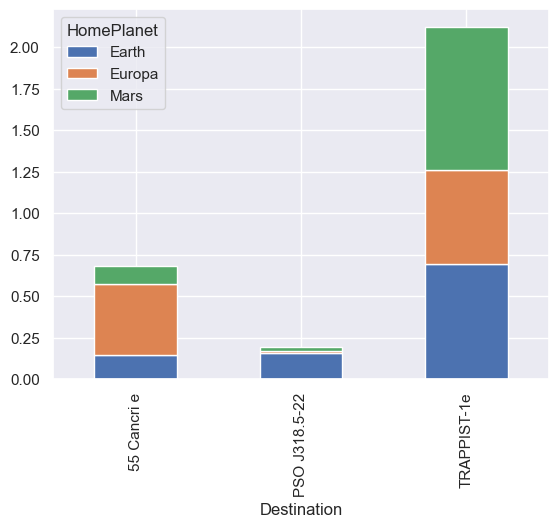

In [771]:
#plot relative frequencies of home planet per destination
homeplanet_destination = all.groupby(['HomePlanet', 'Destination']).size().unstack().T
homeplanet_destination = homeplanet_destination.div(homeplanet_destination.sum(axis=0), axis=1)
homeplanet_destination.plot.bar(stacked=True)

# People going to 'PSO J318.5-22' most likely from Earth, People going to '55 Cancri e' most likely from Europa, People going to 'TRAPPIST-1e' most likely from Mars
# fill the na vaues in 'HomePlanet' with the most common value of that person's 'Destination' and that person's 'Deck'
print(f'HomePlanet\nNA before: {all["HomePlanet"].isna().sum()}')
all['HomePlanet'] = all['HomePlanet'].fillna(all.groupby(['Destination', 'Deck'])['HomePlanet'].transform(lambda x: x.mode()[0]))
print(f'NA after: {all["HomePlanet"].isna().sum()}')

# fill the remaining missing values in 'HomePlanet' with the most common value of that person's Deck
print(f'HomePlanet\nNA before: {all["HomePlanet"].isna().sum()}')
all['HomePlanet'] = all['HomePlanet'].fillna(all.groupby('Deck')['HomePlanet'].transform(lambda x: x.mode()[0]))
print(f'NA after: {all["HomePlanet"].isna().sum()}')

# fill the na values in 'Destination' with the most common value of that person's 'HomePlanet' and that person's 'Deck'
print(f'Destination\nNA before: {all["Destination"].isna().sum()}')
all['Destination'] = all['Destination'].fillna(all.groupby(['HomePlanet', 'Deck'])['Destination'].transform(lambda x: x.mode()[0]))
print(f'NA after: {all["Destination"].isna().sum()}')

<Axes: xlabel='Deck'>

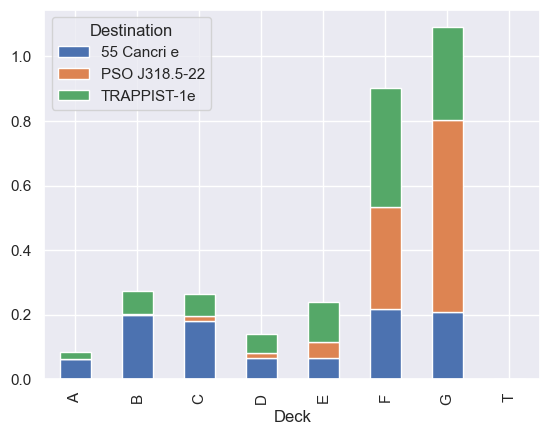

In [772]:
# plot destinatino per deck
destination_deck = all.groupby(['Destination', 'Deck']).size().unstack().T
destination_deck = destination_deck.div(destination_deck.sum(axis=0), axis=1)
destination_deck.plot.bar(stacked=True)

In [773]:
# Fill the na in service variables with the median of people with the same home planet
print(f'Room Service\nNA before: {all["RoomService"].isna().sum()}')
all['RoomService'] = all['RoomService'].fillna(all.groupby('HomePlanet')['RoomService'].transform('median'))
print(f'NA after: {all["RoomService"].isna().sum()}\n')
print(f'Food Court\nNA before: {all["FoodCourt"].isna().sum()}')
all['FoodCourt'] = all['FoodCourt'].fillna(all.groupby('HomePlanet')['FoodCourt'].transform('median'))
print(f'NA after: {all["FoodCourt"].isna().sum()}\n')
print(f'Shopping Mall\nNA before: {all["ShoppingMall"].isna().sum()}')
all['ShoppingMall'] = all['ShoppingMall'].fillna(all.groupby('HomePlanet')['ShoppingMall'].transform('median'))
print(f'NA after: {all["ShoppingMall"].isna().sum()}\n')
print(f'Spa\nNA before: {all["Spa"].isna().sum()}')
all['Spa'] = all['Spa'].fillna(all.groupby('HomePlanet')['Spa'].transform('median'))
print(f'NA after: {all["Spa"].isna().sum()}\n')
print(f'VR Deck\nNA before: {all["VRDeck"].isna().sum()}')
all['VRDeck'] = all['VRDeck'].fillna(all.groupby('HomePlanet')['VRDeck'].transform('median'))
print(f'NA after: {all["VRDeck"].isna().sum()}\n')

# Create a new feature 'TotalServices' which is the sum of all services
all['TotalServices'] = all['RoomService'] + all['FoodCourt'] + all['ShoppingMall'] + all['Spa'] + all['VRDeck']


Room Service
NA before: 170
NA after: 0

Food Court
NA before: 179
NA after: 0

Shopping Mall
NA before: 174
NA after: 0

Spa
NA before: 175
NA after: 0

VR Deck
NA before: 173
NA after: 0



In [776]:
all.isna().sum()

HomePlanet          0
CryoSleep           0
Destination         0
Age                 0
VIP                 0
RoomService         0
FoodCourt           0
ShoppingMall        0
Spa                 0
VRDeck              0
Transported      4277
Set                 0
Deck                0
Side                0
TravelSize          0
TotalServices       0
dtype: int64

In [ ]:
# boxplots of room service, food court, shopping mall, spa, vr deck, create them separately for clarity, and only from non-cryosleep passengers, and turn it into a function reusable for all features like Deck. so the function plots all services for one categorical feature.

# also remove the x-axis labels for the first 4 plots
import seaborn as sns
import matplotlib.pyplot as plt

def plot_services_per_feature(feature):
    fig, axs = plt.subplots(5, 1, figsize=(10, 20))
    for i, service in enumerate(['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']):
        sns.boxplot(data=all[all['CryoSleep'] == False], x=feature, y=service, ax=axs[i])
        axs[i].set_xlabel('')
    plt.show()

plot_services_per_feature('Deck')
plot_services_per_feature('Side')
plot_services_per_feature('HomePlanet')
plot_services_per_feature('Destination')
plot_services_per_feature('VIP')
plot_services_per_feature('TravelSize')

